# PINN logistic growth with heteroscedastic AR(1) noise (linear $H$ with $dN/dt = N H(N)$)

This notebook runs the like-for-like linear-$H$ version where the dynamics model is constrained to $H(N)=aN+b$ and the ODE uses $N\,H(N)$.


In [4]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), 'linear_H'))

from config import ExperimentConfig
from data import generate_synthetic_data, compute_noise_summary
from training import fit_multi_ic_pinn, fit_sigma_ar1_repeated
from utils import set_seed, mean_and_ci
from diagnostics import plot_percentage_error_vs_state


In [11]:
# ============================================================
# Setup
# ============================================================
cfg = ExperimentConfig(rho_true=0.8)
device = torch.device(cfg.device)

set_seed(cfg.seed_torch, cfg.seed_numpy)

# ============================================================
# Generate data
# ============================================================
data = generate_synthetic_data(cfg, device)

t_obs = data["t_obs"]
t_plot = data["t_plot"]
N_grid = data["N_grid"]
y_true_all = data["y_true_all"]
y_data_all = data["y_data_all"]
noise_all = data["noise_all"]
H_grid_true = data["H_grid_true"]
G_grid_true = data["G_grid_true"]
sigma_true_grid = data["sigma_true_grid"]

n_ics = len(cfg.N0_list)

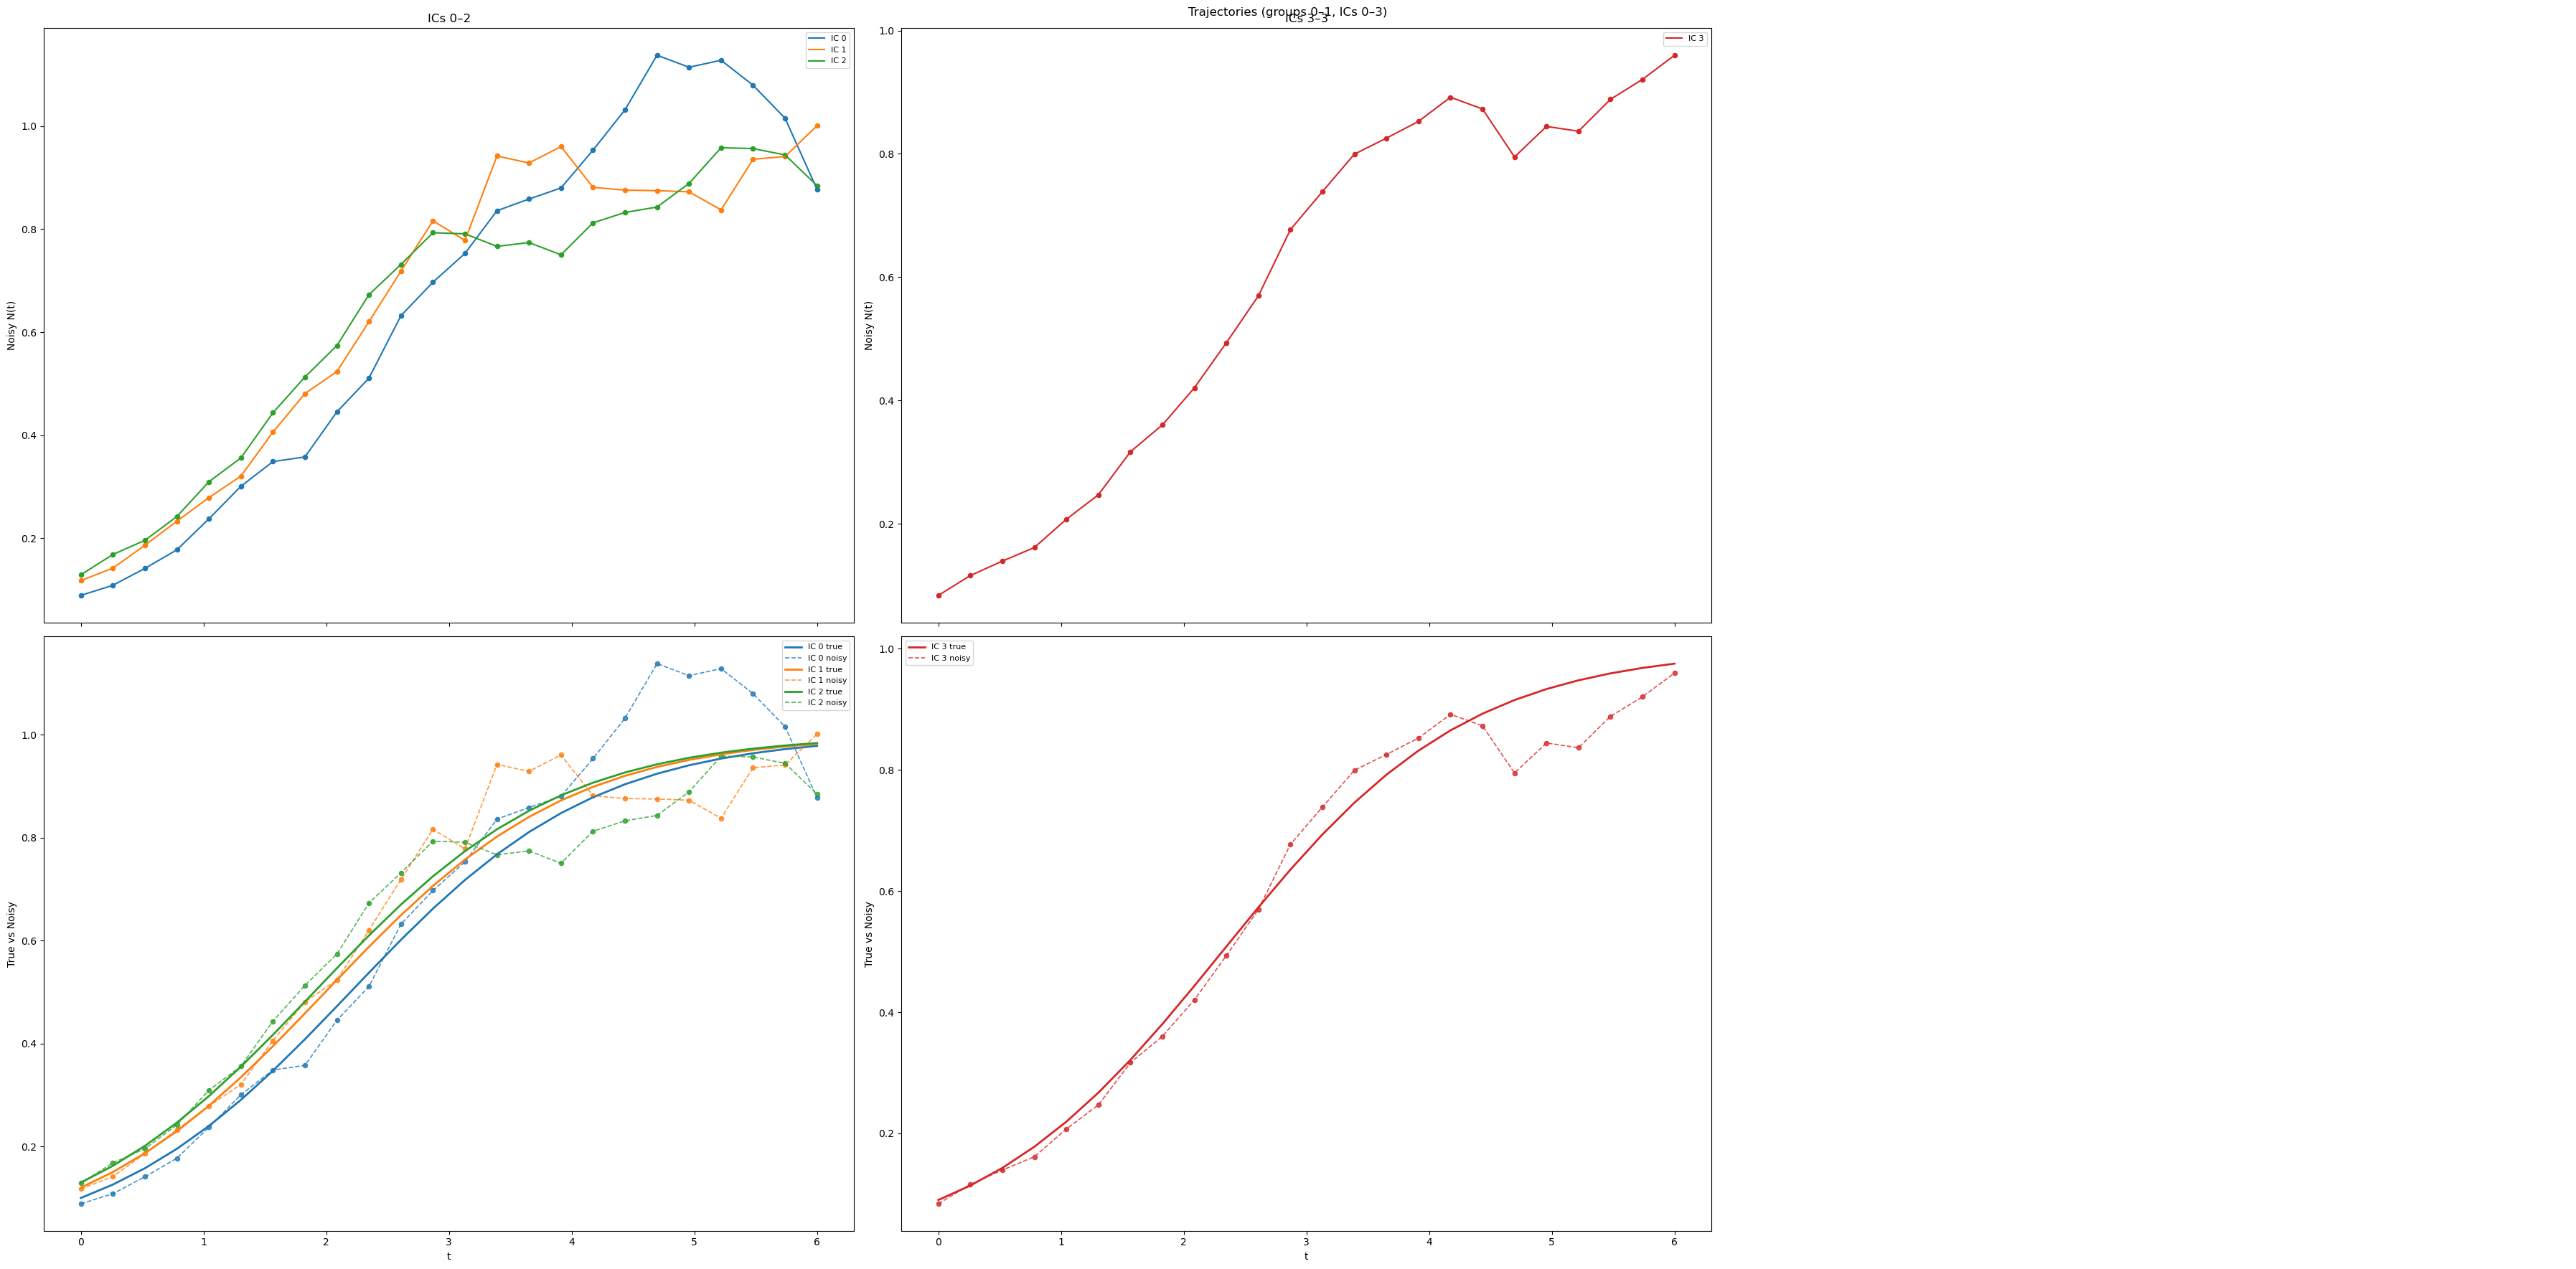

In [12]:
import matplotlib.pyplot as plt
import torch
import math


def plot_noisy_and_true_trajectories(
    t_obs,
    y_data_all,
    y_true_all,
    ics_per_plot=3,
    plots_per_row=3,
    outpath_prefix=None,
):

    t = torch.as_tensor(t_obs).cpu().numpy().reshape(-1)
    y_data = torch.as_tensor(y_data_all).cpu().numpy().squeeze(-1)
    y_true = torch.as_tensor(y_true_all).cpu().numpy().squeeze(-1)

    n_ics = y_data.shape[0]

    n_groups = math.ceil(n_ics / ics_per_plot)
    n_figs = math.ceil(n_groups / plots_per_row)

    for fig_id in range(n_figs):

        group_start = fig_id * plots_per_row
        group_end = min(group_start + plots_per_row, n_groups)
        n_cols_used = group_end - group_start

        fig, axes = plt.subplots(
            2,
            plots_per_row,
            figsize=(3 * 4 * plots_per_row, 3 * 6),
            sharex=True,
        )

        if plots_per_row == 1:
            axes = axes.reshape(2, 1)

        for j in range(plots_per_row):

            if j >= n_cols_used:
                axes[0, j].axis("off")
                axes[1, j].axis("off")
                continue

            group_idx = group_start + j
            ic_start = group_idx * ics_per_plot
            ic_end = min(ic_start + ics_per_plot, n_ics)

            for ic_idx in range(ic_start, ic_end):

                color = plt.cm.tab10(ic_idx % 10)
                label = f"IC {ic_idx}"

                # ---- row 1: noisy only ----
                axes[0, j].plot(
                    t, y_data[ic_idx],
                    color=color,
                    linewidth=1.5,
                    label=label
                )
                axes[0, j].scatter(
                    t, y_data[ic_idx],
                    color=color,
                    s=20
                )

                # ---- row 2: noisy + true overlay ----
                axes[1, j].plot(
                    t, y_true[ic_idx],
                    color=color,
                    linewidth=2,
                    linestyle="-",
                    label=f"{label} true"
                )

                axes[1, j].plot(
                    t, y_data[ic_idx],
                    color=color,
                    linewidth=1.2,
                    linestyle="--",
                    alpha=0.8,
                    label=f"{label} noisy"
                )

                axes[1, j].scatter(
                    t, y_data[ic_idx],
                    color=color,
                    s=20,
                    alpha=0.8
                )

            axes[0, j].set_title(f"ICs {ic_start}–{ic_end - 1}")
            axes[0, j].set_ylabel("Noisy N(t)")

            axes[1, j].set_ylabel("True vs Noisy")
            axes[1, j].set_xlabel("t")

            axes[0, j].legend(fontsize=8)
            axes[1, j].legend(fontsize=8)

        fig.suptitle(
            f"Trajectories (groups {group_start}–{group_end - 1}, "
            f"ICs {group_start * ics_per_plot}–{min(group_end * ics_per_plot, n_ics) - 1})"
        )

        plt.tight_layout()

        if outpath_prefix is not None:
            plt.savefig(
                f"{outpath_prefix}_{fig_id}.png",
                dpi=180,
                bbox_inches="tight",
            )

        plt.show()


plot_noisy_and_true_trajectories(
    t_obs,
    y_data_all,
    y_true_all,
)

In [13]:
# ============================================================
# Noise summary
# ============================================================
stats = compute_noise_summary(
    y_true_all=y_true_all,
    y_data_all=y_data_all,
    noise_sig_coeff=cfg.noise_sig_coeff,
    gamma=cfg.gamma,
)

print("\nNoise summary")
print("-------------")
print(f"rho_true: {cfg.rho_true:.4f}")
print(f"mean signed noise: {stats['noise_np'].mean():.6e}")
print(f"std signed noise : {stats['noise_np'].std(ddof=1):.6e}")
print(f"mean abs noise   : {stats['abs_noise_np'].mean():.6e}")
print(f"RMSE noise       : {np.sqrt(np.mean(stats['noise_np']**2)):.6e}")
print(f"mean sigma_true  : {stats['sigma_true_obs_np'].mean():.6e}")


Noise summary
-------------
rho_true: 0.8000
mean signed noise: 2.616887e-03
std signed noise : 6.436768e-02
mean abs noise   : 4.587851e-02
RMSE noise       : 6.408501e-02
mean sigma_true  : 6.299866e-02


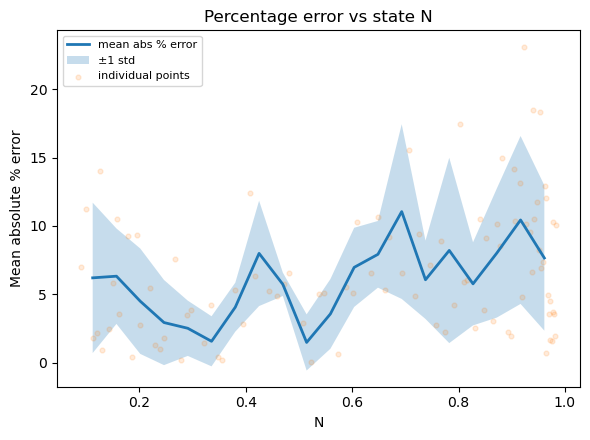

In [14]:
plot_percentage_error_vs_state(y_true_all, y_data_all)

In [15]:
# ============================================================
# Train multi-IC PINN with linear H
# ============================================================

cfg.n_epochs_pinn = 5000
cfg.lambda_h0 = 1
cfg.hidden_dim_sol = 32
cfg.hidden_dim_dyn = 4
# Note: DynamicsNet now enforces H(N) = a*N + b

pinn_out = fit_multi_ic_pinn(
    cfg=cfg,
    y_data_all=y_data_all,
    t_obs=t_obs,
    t_plot=t_plot,
    N_grid=N_grid,
    n_ics=n_ics,
    device=device,
)

rhs_mean = pinn_out["rhs_mean"]
rhs_lo = pinn_out["rhs_lo"]
rhs_hi = pinn_out["rhs_hi"]

traj_mean_per_ic = pinn_out["rhs_rollout_traj_mean_per_ic"]
traj_lo_per_ic = pinn_out["rhs_rollout_traj_lo_per_ic"]
traj_hi_per_ic = pinn_out["rhs_rollout_traj_hi_per_ic"]

obs_fit_mean_per_ic = pinn_out["rhs_rollout_obs_fit_mean_per_ic"]
obs_fit_lo_per_ic = pinn_out["rhs_rollout_obs_fit_lo_per_ic"]
obs_fit_hi_per_ic = pinn_out["rhs_rollout_obs_fit_hi_per_ic"]

PINN | Split 1/4 | Epoch 1/5000 | PINN=7.043417e-01 | Optim=7.043417e-01 | Data=6.953623e-01 | Phys=8.979295e-03 | H0=0.000000e+00 | IC=1.245812e-02 | Heldout=3.089143e-02
PINN | Split 1/4 | Epoch 500/5000 | PINN=2.947627e-03 | Optim=2.947627e-03 | Data=2.540736e-03 | Phys=4.068906e-04 | H0=0.000000e+00 | IC=6.662197e-04 | Heldout=2.929530e-02
PINN | Split 1/4 | Epoch 1000/5000 | PINN=2.455283e-03 | Optim=2.455283e-03 | Data=2.072935e-03 | Phys=3.823480e-04 | H0=0.000000e+00 | IC=5.296094e-04 | Heldout=2.203179e-02
PINN | Split 1/4 | Epoch 1500/5000 | PINN=2.054160e-03 | Optim=2.054160e-03 | Data=1.789447e-03 | Phys=2.647129e-04 | H0=0.000000e+00 | IC=2.673283e-04 | Heldout=1.608047e-02
PINN | Split 1/4 | Epoch 2000/5000 | PINN=1.856380e-03 | Optim=1.856380e-03 | Data=1.594387e-03 | Phys=2.619928e-04 | H0=0.000000e+00 | IC=6.734602e-05 | Heldout=1.250897e-02
PINN | Split 1/4 | Epoch 2500/5000 | PINN=1.708681e-03 | Optim=1.708681e-03 | Data=1.482783e-03 | Phys=2.258982e-04 | H0=0.000000

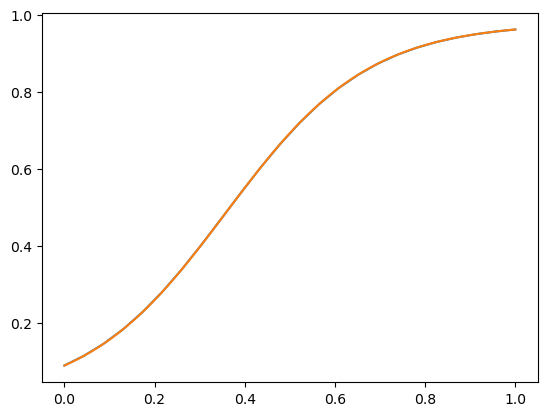

In [16]:
plt.plot(np.linspace(0,1,24), obs_fit_mean_per_ic[0])
plt.plot(np.linspace(0,1,200), traj_mean_per_ic[0])

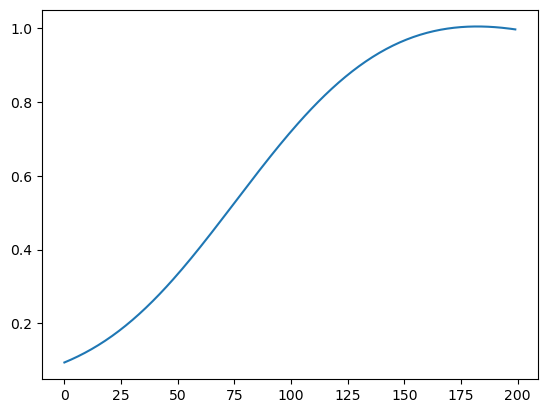

In [ ]:
print(len(obs_fit_mean_per_ic[0]))
print(len(traj_mean_per_ic[0]))


In [17]:
# ============================================================
# Learn sigma(N), rho from PINN residuals
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    resid_pinn_seq_np = y_data_np - obs_fit_mean_all
    N_pinn_seq_np = np.maximum(obs_fit_mean_all, 1e-8)

N_pinn_seq = torch.tensor(N_pinn_seq_np[..., None], dtype=torch.float32, device=device)
resid_pinn_seq = torch.tensor(resid_pinn_seq_np[..., None], dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_ar1_repeated(
    N_seq_all=N_pinn_seq,
    resid_seq_all=resid_pinn_seq,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_1,
    seed_offset_model=cfg.sigma_model_seed_base_1,
    label="PINN-sigma-AR1",
    print_every=cfg.print_every_sigma,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)
rho_pinn_mean = sigma_pinn_results["best_rhos"].mean()

PINN-sigma-AR1 | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=-5.616336e-01 | Train NLL=-5.616772e-01 | Val Total=-5.834070e-01
PINN-sigma-AR1 | Repeat 1/1 | Epoch 250/2000 | rho=0.7514 | Train Total=-3.052859e+00 | Train NLL=-3.053018e+00 | Val Total=-3.162337e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 500/2000 | rho=0.7193 | Train Total=-3.068428e+00 | Train NLL=-3.068591e+00 | Val Total=-3.170146e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 750/2000 | rho=0.7212 | Train Total=-3.089974e+00 | Train NLL=-3.090171e+00 | Val Total=-3.182141e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1000/2000 | rho=0.7221 | Train Total=-3.099993e+00 | Train NLL=-3.100232e+00 | Val Total=-3.184359e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1250/2000 | rho=0.7225 | Train Total=-3.102033e+00 | Train NLL=-3.102297e+00 | Val Total=-3.183665e+00
PINN-sigma-AR1 | Repeat 1/1 | Epoch 1500/2000 | rho=0.7223 | Train Total=-3.103121e+00 | Train NLL=-3.103402e+00 | Val Total=-3.183682e+00
PINN-sigma-AR1 | Repeat 1/1 | Epo

In [18]:
# ============================================================
# Learn sigma(N), rho from true residuals
# ============================================================
with torch.no_grad():
    N_true_seq_np = y_true_all.squeeze(-1).cpu().numpy()
    resid_true_seq_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy()
    N_true_seq_np = np.maximum(N_true_seq_np, 1e-8)

N_true_seq = torch.tensor(N_true_seq_np[..., None], dtype=torch.float32, device=device)
resid_true_seq = torch.tensor(resid_true_seq_np[..., None], dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_ar1_repeated(
    N_seq_all=N_true_seq,
    resid_seq_all=resid_true_seq,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_2,
    seed_offset_model=cfg.sigma_model_seed_base_2,
    label="TRUE-sigma-AR1",
    print_every=cfg.print_every_sigma,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)
rho_truefit_mean = sigma_truefit_results["best_rhos"].mean()

TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=2.658771e+00 | Train NLL=-5.904813e-01 | Val Total=2.210600e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 250/2000 | rho=0.8077 | Train Total=-2.710773e+00 | Train NLL=-2.710879e+00 | Val Total=-2.891574e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 500/2000 | rho=0.8035 | Train Total=-2.850462e+00 | Train NLL=-2.850593e+00 | Val Total=-3.003907e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 750/2000 | rho=0.7974 | Train Total=-3.032352e+00 | Train NLL=-3.032522e+00 | Val Total=-3.128978e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1000/2000 | rho=0.7725 | Train Total=-3.058526e+00 | Train NLL=-3.058720e+00 | Val Total=-3.137298e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1250/2000 | rho=0.7706 | Train Total=-3.067817e+00 | Train NLL=-3.068029e+00 | Val Total=-3.146543e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch 1500/2000 | rho=0.7740 | Train Total=-3.072802e+00 | Train NLL=-3.073031e+00 | Val Total=-3.152240e+00
TRUE-sigma-AR1 | Repeat 1/1 | Epoch

In [19]:
# ============================================================
# Residual diagnostics
# ============================================================
with torch.no_grad():
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()
    residuals_all = y_data_np - np.array(obs_fit_mean_per_ic)
    N_fit_all = np.maximum(np.array(obs_fit_mean_per_ic), 1e-8)

    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(N_fit_all[..., None], dtype=torch.float32, device=device)
    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()

    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)
    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

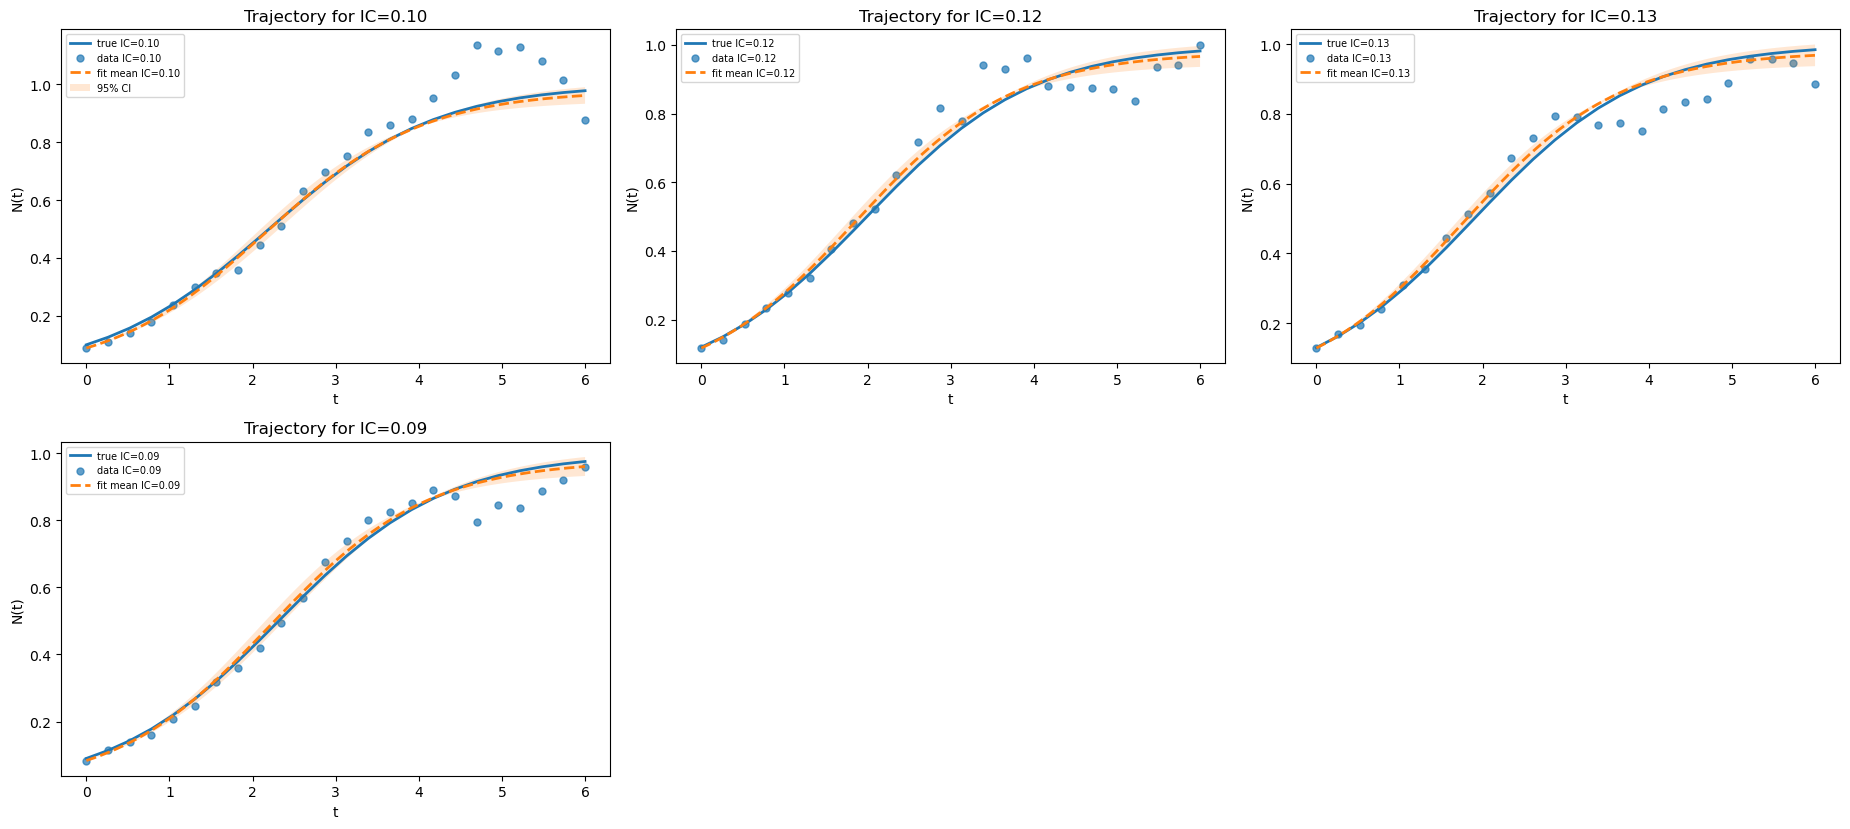

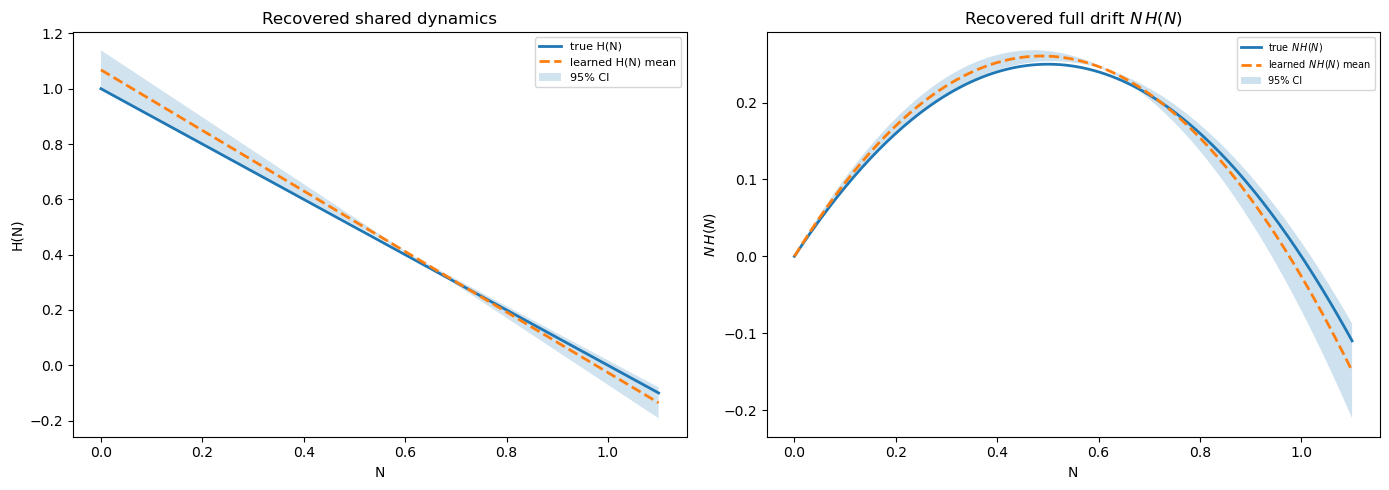

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_19828/1173952699.py:201: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[2].set_yscale("log")


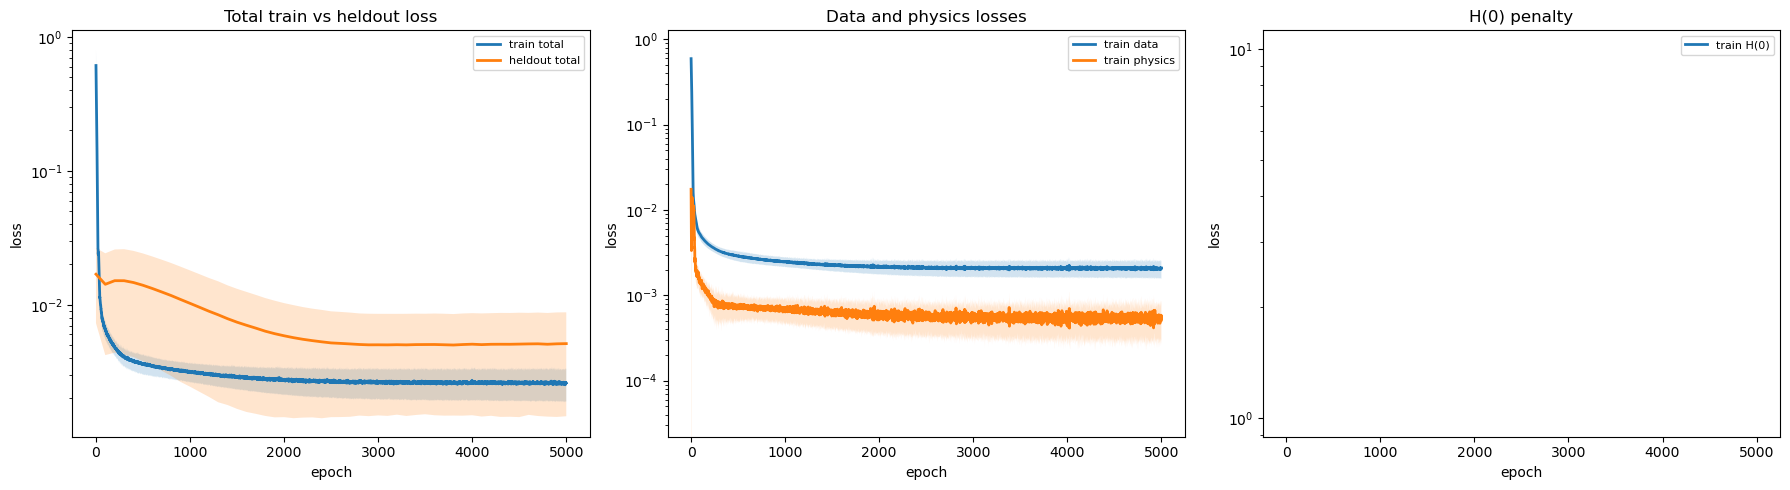

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 1: one subplot per IC
# ============================================================
ncols = 3
nrows = math.ceil(n_ics / ncols)

fig_ic, axes_ic = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.2 * nrows), squeeze=False)
axes_ic = axes_ic.flatten()

t_obs_np = t_obs.cpu().numpy()
t_plot_np = t_plot.squeeze(1).cpu().numpy()

for i in range(n_ics):
    ax = axes_ic[i]

    ax.plot(
        t_obs_np,
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={cfg.N0_list[i]:.2f}"
    )
    ax.scatter(
        t_obs_np,
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={cfg.N0_list[i]:.2f}"
    )
    ax.plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={cfg.N0_list[i]:.2f}"
    )
    ax.fill_between(
        t_plot_np,
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
        label="95% CI" if i == 0 else None
    )

    ax.set_xlabel("t")
    ax.set_ylabel("N(t)")
    ax.set_title(f"Trajectory for IC={cfg.N0_list[i]:.2f}")
    ax.legend(fontsize=7)

# Hide any unused axes
for j in range(n_ics, len(axes_ic)):
    axes_ic[j].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: summary plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

N_grid_np = N_grid.squeeze(1).cpu().numpy()
H_true_np = H_grid_true.squeeze(1).cpu().numpy()

# full drift = N * H(N)
drift_true = N_grid_np * H_true_np
drift_mean = N_grid_np * rhs_mean
drift_lo = N_grid_np * rhs_lo
drift_hi = N_grid_np * rhs_hi

# ------------------------------------------------------------
# 1. Recovered shared factor dynamics
# ------------------------------------------------------------
axes[0].plot(
    N_grid_np,
    H_true_np,
    linewidth=2,
    label="true H(N)"
)
axes[0].plot(
    N_grid_np,
    rhs_mean,
    "--",
    linewidth=2,
    label="learned H(N) mean"
)
axes[0].fill_between(
    N_grid_np,
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("H(N)")
axes[0].set_title("Recovered shared dynamics")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2. Full drift N H(N)
# ------------------------------------------------------------
axes[1].plot(
    N_grid_np,
    drift_true,
    linewidth=2,
    label=r"true $N\,H(N)$"
)
axes[1].plot(
    N_grid_np,
    drift_mean,
    "--",
    linewidth=2,
    label=r"learned $N\,H(N)$ mean"
)
axes[1].fill_between(
    N_grid_np,
    drift_lo,
    drift_hi,
    alpha=0.22,
    label="95% CI"
)
axes[1].set_xlabel("N")
axes[1].set_ylabel(r"$N\,H(N)$")
axes[1].set_title(r"Recovered full drift $N\,H(N)$")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


# ============================================================
# Loss plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_init = np.arange(cfg.n_epochs_pinn)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(
    pinn_out["train_pinn_total_histories"]
)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(
    pinn_out["train_data_histories"]
)
train_phys_mean, train_phys_lo, train_phys_hi = mean_and_ci(
    pinn_out["train_phys_histories"]
)
train_h0_mean, train_h0_lo, train_h0_hi = mean_and_ci(
    pinn_out["train_h0_histories"]
)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(
    pinn_out["val_total_histories"]
)

# ------------------------------------------------------------
# 1) Total training loss + total heldout loss
# ------------------------------------------------------------
axes[0].plot(epochs_init, train_pinn_total_mean, linewidth=2, label="train total")
axes[0].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)

mask = ~np.isnan(val_total_mean) & ~np.isnan(val_total_lo) & ~np.isnan(val_total_hi)

axes[0].plot(epochs_init[mask], val_total_mean[mask], linewidth=2, label="heldout total")
axes[0].fill_between(
    epochs_init[mask],
    val_total_lo[mask],
    val_total_hi[mask],
    alpha=0.2
)

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total train vs heldout loss")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2) Data loss + physics loss
# ------------------------------------------------------------
axes[1].plot(epochs_init, train_data_mean, linewidth=2, label="train data")
axes[1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)

axes[1].plot(epochs_init, train_phys_mean, linewidth=2, label="train physics")
axes[1].fill_between(epochs_init, train_phys_lo, train_phys_hi, alpha=0.2)

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Data and physics losses")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3) H(0) loss
# ------------------------------------------------------------
axes[2].plot(epochs_init, train_h0_mean, linewidth=2, label="train H(0)")
axes[2].fill_between(epochs_init, train_h0_lo, train_h0_hi, alpha=0.2)

axes[2].set_yscale("log")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("loss")
axes[2].set_title("H(0) penalty")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
print("\nSummary")
print("-------")
print(f"Number of trajectories: {n_ics}")
print(f"IC values: {cfg.N0_list}")
print(f"Mean PINN best validation loss: {pinn_out['best_val_losses'].mean():.6e}")
print(f"Mean PINN best epoch: {pinn_out['best_epochs'].mean():.2f}")
print(f"PINN residual rho mean: {rho_pinn_mean:.4f}")
print(f"True residual rho mean: {rho_truefit_mean:.4f}")
print(f"Empirical standardized residual rho: {rho_empirical:.4f}")


Summary
-------
Number of trajectories: 4
IC values: (0.1, 0.12, 0.13, 0.09)
Mean PINN best validation loss: 4.835023e-03
Mean PINN best epoch: 3349.00
PINN residual rho mean: 0.7220
True residual rho mean: 0.7806
Empirical standardized residual rho: 0.7050


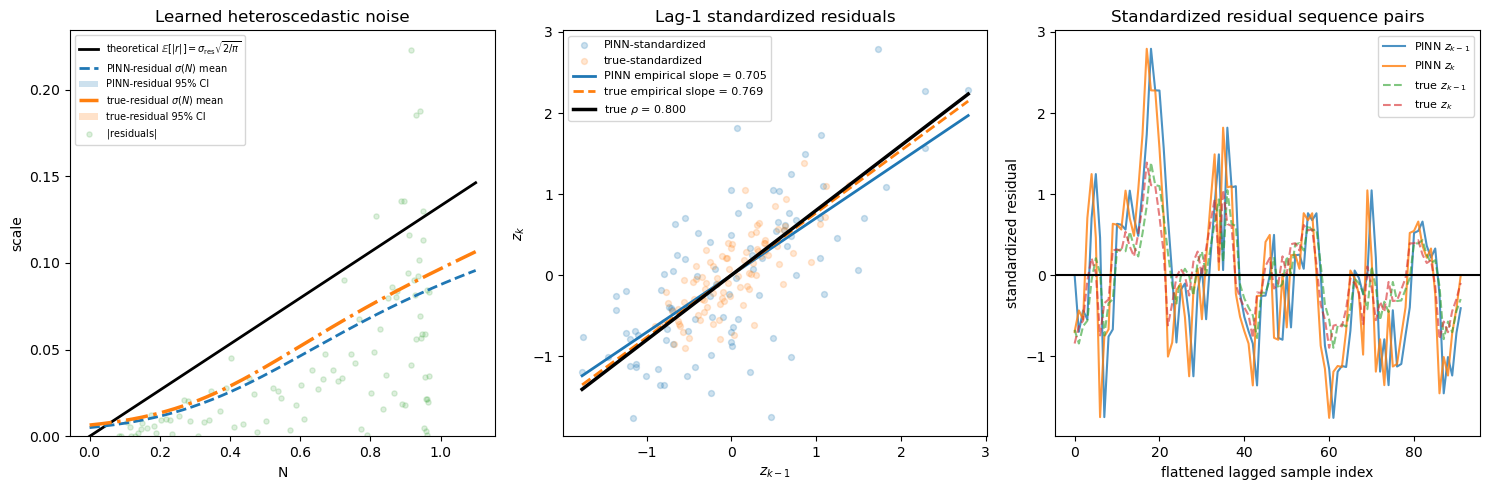

PINN empirical lag-1 slope:  0.705011
True empirical lag-1 slope:  0.768870
True rho:                    0.800000


In [23]:
# ============================================================
# Noise + AR(1) residual diagnostics on one row
# ============================================================
with torch.no_grad():
    # from synthetic data dict
    y_true_all = data["y_true_all"]             # [n_ics, T, 1]
    y_data_all = data["y_data_all"]             # [n_ics, T, 1]
    N_grid = data["N_grid"]                     # [M, 1]
    sigma_true_grid = data["sigma_true_grid"]   # innovation sigma on grid, [M, 1]

    # fitted trajectories from PINN output
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)   # [n_ics, T]

    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    # residuals against fitted mean trajectories
    residuals_all = y_data_np - obs_fit_mean_all       # [n_ics, T]
    N_fit_all = np.maximum(obs_fit_mean_all, 1e-8)     # [n_ics, T]

    # true residuals against true latent trajectories
    true_residuals_all = y_data_np - y_true_np         # [n_ics, T]
    N_true_all = np.maximum(y_true_np, 1e-8)           # [n_ics, T]

    # evaluate learned sigma(N) from PINN residual fit
    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(
        N_fit_all[..., None], dtype=torch.float32, device=device
    )                                                   # [n_ics, T, 1]

    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()  # [n_ics, T]

    # AR(1): true innovation sigma and true residual std / expected abs residual
    sigma_true_innovation_grid = sigma_true_grid.squeeze(1).cpu().numpy()  # [M]
    sigma_true_residstd_grid = sigma_true_innovation_grid / np.sqrt(1.0 - cfg.rho_true ** 2)
    expected_abs_resid_grid = sigma_true_residstd_grid * np.sqrt(2.0 / np.pi)

    # evaluate theoretical curves at fitted states too, for optional diagnostics
    sigma_true_innovation_fit = cfg.noise_sig_coeff * np.maximum(N_fit_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_fit = sigma_true_innovation_fit / np.sqrt(1.0 - cfg.rho_true ** 2)

    # true residual std evaluated at the true latent states
    sigma_true_innovation_true = cfg.noise_sig_coeff * np.maximum(N_true_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_true = sigma_true_innovation_true / np.sqrt(1.0 - cfg.rho_true ** 2)

    # standardized residuals using learned sigma fit
    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)   # [n_ics, T]

    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

    # standardized TRUE residuals using TRUE residual std
    z_true_all = true_residuals_all / np.maximum(sigma_true_residstd_true, 1e-8)  # [n_ics, T]

    z_true_prev = z_true_all[:, :-1].reshape(-1)
    z_true_next = z_true_all[:, 1:].reshape(-1)

    rho_empirical_true = np.sum(z_true_prev * z_true_next) / np.maximum(
        np.sum(z_true_prev ** 2), 1e-12
    )

    # flattened versions for plotting
    N_fit_flat = N_fit_all.reshape(-1)
    residuals_flat = residuals_all.reshape(-1)
    abs_residuals_flat = np.abs(residuals_flat)
    sigma_fit_flat = sigma_fit_all.reshape(-1)
    sigma_true_residstd_fit_flat = sigma_true_residstd_fit.reshape(-1)
    z_flat = z_all.reshape(-1)

# ============================================================
# Plot row: heteroscedastic noise + AR(1) diagnostics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

N_grid_np = N_grid.squeeze(1).cpu().numpy()

# ------------------------------------------------------------
# 1. Learned heteroscedastic noise
# ------------------------------------------------------------

axes[0].plot(
    N_grid_np,
    expected_abs_resid_grid,
    linewidth=2,
    linestyle="-",
    color="black",
    label=r"theoretical $\mathbb{E}[|r|]=\sigma_{\rm res}\sqrt{2/\pi}$"
)
axes[0].plot(
    N_grid_np,
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI"
)
axes[0].plot(
    N_grid_np,
    sigma_truefit_mean,
    linewidth=2.5,
    linestyle="-.",
    label=r"true-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI"
)
axes[0].scatter(
    N_fit_flat,
    abs_residuals_flat,
    s=14,
    alpha=0.16,
    label=r"$|$residuals$|$"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("scale")
axes[0].set_title("Learned heteroscedastic noise")
axes[0].legend(fontsize=7)

ymax0 = max(
    np.max(abs_residuals_flat) if abs_residuals_flat.size else 0.0,
    np.max(sigma_pinn_hi) if len(sigma_pinn_hi) else 0.0,
    np.max(sigma_truefit_hi) if len(sigma_truefit_hi) else 0.0,
    np.max(sigma_true_residstd_grid) if len(sigma_true_residstd_grid) else 0.0,
)
axes[0].set_ylim(0, 1.05 * ymax0)

# ------------------------------------------------------------
# 2. Lag-1 standardized residual scatter
# ------------------------------------------------------------
axes[1].scatter(z_prev, z_next, s=18, alpha=0.22, label="PINN-standardized")
axes[1].scatter(z_true_prev, z_true_next, s=18, alpha=0.18, label="true-standardized")

xmin = min(z_prev.min(), z_next.min(), z_true_prev.min(), z_true_next.min())
xmax = max(z_prev.max(), z_next.max(), z_true_prev.max(), z_true_next.max())

axes[1].plot(
    [xmin, xmax],
    [rho_empirical * xmin, rho_empirical * xmax],
    linewidth=2,
    label=fr"PINN empirical slope = {rho_empirical:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [rho_empirical_true * xmin, rho_empirical_true * xmax],
    linewidth=2,
    linestyle="--",
    label=fr"true empirical slope = {rho_empirical_true:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [cfg.rho_true * xmin, cfg.rho_true * xmax],
    color="black",
    linewidth=2.5,
    label=fr"true $\rho$ = {cfg.rho_true:.3f}"
)
axes[1].set_xlabel(r"$z_{k-1}$")
axes[1].set_ylabel(r"$z_k$")
axes[1].set_title("Lag-1 standardized residuals")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3. Standardized residual sequence pairs
# ------------------------------------------------------------
axes[2].plot(z_prev, label=r"PINN $z_{k-1}$", alpha=0.8)
axes[2].plot(z_next, label=r"PINN $z_k$", alpha=0.8)
axes[2].plot(z_true_prev, label=r"true $z_{k-1}$", alpha=0.6, linestyle="--")
axes[2].plot(z_true_next, label=r"true $z_k$", alpha=0.6, linestyle="--")
axes[2].axhline(0.0, color="black", linewidth=1.5)
axes[2].set_xlabel("flattened lagged sample index")
axes[2].set_ylabel("standardized residual")
axes[2].set_title("Standardized residual sequence pairs")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"PINN empirical lag-1 slope:  {rho_empirical:.6f}")
print(f"True empirical lag-1 slope:  {rho_empirical_true:.6f}")
print(f"True rho:                    {cfg.rho_true:.6f}")

## rPINN extension: posterior over trajectories and linear $H(N)$

This section extends the deterministic PINN notebook with an rPINN-style randomized MAP ensemble.

**Assumes you have already run the earlier notebook cells** so the following objects exist:

- `cfg`, `device`
- `y_data_all`, `t_obs`, `t_plot`, `N_grid`
- `sigma_pinn_results` (learned data uncertainty + AR(1) fit)
- `sigma_phys_results` (learned physics uncertainty fit)
- `H_grid_true` (optional, for plotting)

This implementation uses:

- the learned `sigma_data(N)` for **time-correlated observation perturbations**
- the learned `rho` in the **AR(1) data NLL**
- the learned `sigma_physics(N)` for **physics-loss perturbations at collocation points**


Fitting sigma_physics(N)...
sigma-physics | repeat 1/1 | epoch 1/3000 | train_total=-4.959533e-03 | train_nll=-5.103612e-03 | val_total=-4.244879e-02
sigma-physics | repeat 1/1 | epoch 250/3000 | train_total=-3.587897e+00 | train_nll=-3.588210e+00 | val_total=-3.594269e+00
sigma-physics | repeat 1/1 | epoch 500/3000 | train_total=-3.605962e+00 | train_nll=-3.606294e+00 | val_total=-3.615835e+00
sigma-physics | repeat 1/1 | epoch 750/3000 | train_total=-3.611753e+00 | train_nll=-3.612102e+00 | val_total=-3.623772e+00
sigma-physics | repeat 1/1 | epoch 1000/3000 | train_total=-3.613138e+00 | train_nll=-3.613491e+00 | val_total=-3.625775e+00
sigma-physics | repeat 1/1 | epoch 1250/3000 | train_total=-3.614407e+00 | train_nll=-3.614759e+00 | val_total=-3.627001e+00
sigma-physics | repeat 1/1 | epoch 1500/3000 | train_total=-3.615865e+00 | train_nll=-3.616219e+00 | val_total=-3.628253e+00
sigma-physics | repeat 1/1 | epoch 1750/3000 | train_total=-3.617480e+00 | train_nll=-3.617839e+00 | va

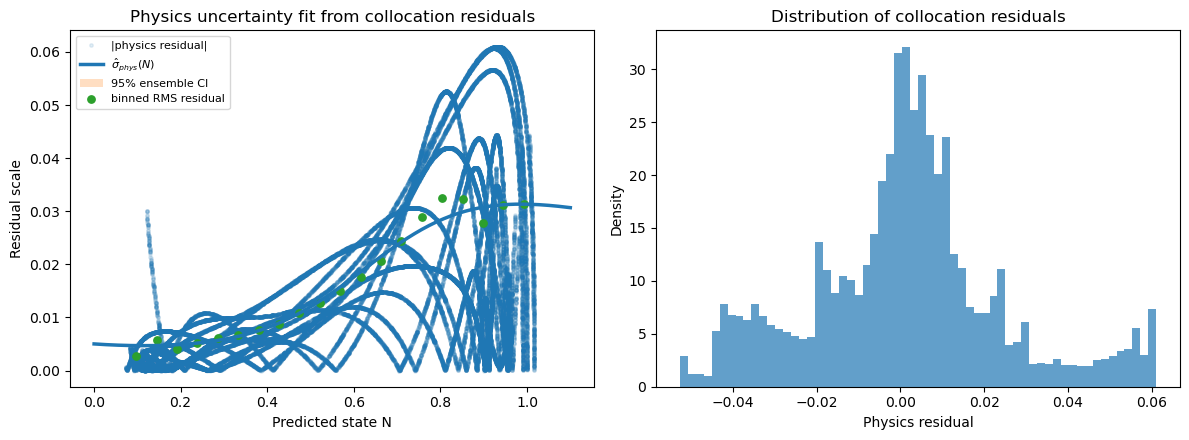

Binned collocation counts:
[1515 2911 2240 1971 1637 1580 1473 1475 1377 1372 1386 1467 1613 1823
 2133 2613 3860 7122 5327 3105]
Best validation losses: [-3.63396764]
Best epochs: [2999]
Saved figure to sigma_physics_fit.png
Saved results to sigma_physics_results.pt


In [24]:
from fit_sigma_physics import PhysicsSigmaConfig, collect_physics_residual_dataset, fit_sigma_physics_repeated, plot_sigma_physics_fit
import torch
phys_cfg = PhysicsSigmaConfig()
device = torch.device(cfg.device)
set_seed(cfg.seed_torch, cfg.seed_numpy)

data_dict = generate_synthetic_data(cfg, device)

print("Collecting collocation residual dataset...")
phys_dataset = collect_physics_residual_dataset(
    cfg=cfg,
    pinn_results=pinn_out,
    device=device,
    n_col_phys=phys_cfg.n_col_phys,
)

N_col_base = N_grid.clone().detach()

phys_cfg.n_repeats = 1
print("Fitting sigma_physics(N)...")
sigma_phys_results = fit_sigma_physics_repeated(
    N_all=phys_dataset["N"],
    resid_all=phys_dataset["resid"],
    N_eval_grid=N_grid,
    N_col_base=N_col_base,
    device=device,
    n_repeats=phys_cfg.n_repeats,
    val_fraction=phys_cfg.val_fraction,
    n_epochs=phys_cfg.n_epochs,
    lr=phys_cfg.lr,
    hidden_dim=phys_cfg.hidden_dim,
    lambda_mon=phys_cfg.lambda_mon,
    lambda_reg=phys_cfg.lambda_reg,
    split_seed_base=phys_cfg.split_seed_base,
    model_seed_base=phys_cfg.model_seed_base,
    print_every=phys_cfg.print_every,
)

plot_sigma_physics_fit(
    dataset=phys_dataset,
    N_grid=N_grid,
    sigma_results=sigma_phys_results,
    outpath="sigma_physics_fit.png",
    n_bins=phys_cfg.n_bins_plot,
)

print("Best validation losses:", sigma_phys_results["best_val_losses"])
print("Best epochs:", sigma_phys_results["best_epochs"])

payload = {
    "physics_dataset": {
        "N": phys_dataset["N"].detach().cpu(),
        "resid": phys_dataset["resid"].detach().cpu(),
        "split_id": phys_dataset["split_id"].detach().cpu(),
        "ic_id": phys_dataset["ic_id"].detach().cpu(),
    },
    "sigma_phys_results": sigma_phys_results,
    "pinn_results": pinn_out,
}
torch.save(payload, "sigma_physics_results.pt")
print("Saved figure to sigma_physics_fit.png")
print("Saved results to sigma_physics_results.pt")




In [25]:

# ============================================================
# rPINN imports and frozen uncertainty models
# ============================================================
from rpinn_models import SigmaEnsembleMean, freeze_module
from rpinn_training import RPINNConfig, fit_rpinn_ensemble
from rpinn_plotting import (
    plot_randomized_targets_example,
    plot_rpinn_dynamics_posterior,
    plot_rpinn_H_posterior,
)

# Use the ensemble mean sigma models from the repeated uncertainty fits.
sigma_data_model = SigmaEnsembleMean(sigma_pinn_results["best_models"]).to(device)
sigma_phys_model = SigmaEnsembleMean(sigma_phys_results["best_models"]).to(device)

freeze_module(sigma_data_model)
freeze_module(sigma_phys_model)

# Use the mean learned AR(1) coefficient from the data-noise fit.
rho_data_rpinn = float(np.mean(sigma_pinn_results["best_rhos"]))

print("rPINN uncertainty inputs")
print("------------------------")
print(f"rho_data_rpinn: {rho_data_rpinn:.4f}")
print(f"num sigma_data models: {len(sigma_pinn_results['best_models'])}")
print(f"num sigma_phys models: {len(sigma_phys_results['best_models'])}")


rPINN uncertainty inputs
------------------------
rho_data_rpinn: 0.7220
num sigma_data models: 1
num sigma_phys models: 1


In [301]:
import copy
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn

from data import odeint_rk4
from losses import h_zero_nonnegative_penalty, pinn_physics_residual
from models import DynamicsNet, SolutionNet
from rpinn_losses import (
    ar1_gaussian_nll_fixed_sigma,
    gaussian_nll_fixed_sigma,
    parameter_anchor_penalty,
    sample_ar1_noise_from_sigma_batch,
)
from rpinn_models import posterior_mean_and_ci

def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)
    
@dataclass
class RPINNConfig:
    device: str = "cpu"
    n_samples: int = 20
    n_epochs: int = 3000
    learning_rate: float = 1e-3
    batch_col: int = 128
    lambda_phys: float = 1.0
    lambda_anchor: float = 1.0
    lambda_h0: float = 1.0
    lambda_ic: float = 0.0
    prior_std: float = 1.0
    hidden_dim_sol: int = 32
    hidden_dim_dyn: int = 32
    dyn_init_seed_base: int = 30000
    sol_init_seed_base: int = 40000
    anchor_seed_base: int = 50000
    perturb_seed_base: int = 60000
    print_every: int = 250
    use_full_time_sequence_for_data: bool = True
    detach_sigma_inputs: bool = True


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net: nn.Module, y0: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    return odeint_rk4(lambda tt, yy: yy * dyn_net(yy), y0, t.squeeze()).squeeze(1)



def _sample_module_anchors(module: nn.Module, prior_std: float) -> List[torch.Tensor]:
    return [prior_std * torch.randn_like(p) for p in module.parameters()]



def _build_sigma_inputs(pred: torch.Tensor, ref: torch.Tensor, detach_sigma_inputs: bool) -> torch.Tensor:
    x = pred if pred is not None else ref
    if detach_sigma_inputs:
        x = x.detach()
    return x



def build_randomized_targets(
    y_data_all: torch.Tensor,
    sigma_data_model: nn.Module,
    rho_data: float,
    device: torch.device,
) -> Dict[str, torch.Tensor]:
    """Create one perturbed observed-data target per rPINN sample.

    The perturbation uses the learned heteroskedastic sigma_data(N) and the
    learned AR(1) correlation rho_data.
    """
    with torch.no_grad():
        sigma_obs = sigma_data_model(y_data_all.to(device))
        noise_obs = sample_ar1_noise_from_sigma_batch(sigma_obs, rho=rho_data)
        y_tilde = y_data_all.to(device) + noise_obs
    return {
        "sigma_obs": sigma_obs,
        "noise_obs": noise_obs,
        "y_tilde": y_tilde,
    }



from typing import Dict, Optional, List
import copy
import numpy as np
import torch
import torch.nn as nn

def fit_single_rpinn_sample(
    cfg: RPINNConfig,
    y_data_all: torch.Tensor,
    t_obs: torch.Tensor,
    t_plot: torch.Tensor,
    N_grid: torch.Tensor,
    sigma_data_model: nn.Module,
    rho_data: float,
    sigma_phys_model: nn.Module,
    sample_id: int,
    fit_map: bool = False,
    map_dyn_state_dict: Optional[Dict[str, torch.Tensor]] = None,
    map_sol_state_dicts: Optional[List[Dict[str, torch.Tensor]]] = None,
    anchor_start_epoch: int = 0,
    anchor_ramp_epochs: int = 0,
    rhat_burnin_epoch: int = 20_000,
    rhat_save_every: int = 100,
    rhat_threshold: float = 1.01,
) -> Dict[str, object]:
    def _flatten_modules_state(modules: List[nn.Module]) -> torch.Tensor:
        flat_chunks = []
        for module in modules:
            for param in module.parameters():
                flat_chunks.append(param.detach().reshape(-1).cpu())
        if len(flat_chunks) == 0:
            raise ValueError("No parameters found to flatten for R-hat computation.")
        return torch.cat(flat_chunks, dim=0)

    def _compute_split_chain_rhat_from_snapshots(
        flat_snapshots: List[torch.Tensor],
    ) -> Dict[str, object]:
        """
        Compute split-chain R-hat from a single chain by splitting the post-burnin
        checkpoint sequence into two halves.
        """
        if len(flat_snapshots) < 4:
            return {
                "available": False,
                "reason": (
                    f"Need at least 4 saved checkpoints after burn-in for split R-hat, "
                    f"got {len(flat_snapshots)}."
                ),
                "n_saved": len(flat_snapshots),
            }

        samples = torch.stack(flat_snapshots, dim=0).numpy()  # (n_samples, n_params)

        if samples.shape[0] % 2 == 1:
            samples = samples[:-1]

        n_samples, n_params = samples.shape
        half = n_samples // 2
        if half < 2:
            return {
                "available": False,
                "reason": (
                    f"Need at least 2 samples per split half for split R-hat, got {half}."
                ),
                "n_saved": int(n_samples),
            }

        chain_1 = samples[:half]
        chain_2 = samples[half:]
        x = np.stack([chain_1, chain_2], axis=0)  # (2, half, n_params)

        m, n, p = x.shape

        chain_means = x.mean(axis=1)             # (m, p)
        chain_vars = x.var(axis=1, ddof=1)       # (m, p)

        W = chain_vars.mean(axis=0)              # (p,)
        B = n * chain_means.var(axis=0, ddof=1)  # (p,)

        var_hat = ((n - 1) / n) * W + (1.0 / n) * B

        with np.errstate(divide="ignore", invalid="ignore"):
            rhat = np.sqrt(var_hat / W)

        rhat = np.where(np.isfinite(rhat), rhat, np.nan)

        valid_mask = np.isfinite(rhat)
        if not np.any(valid_mask):
            return {
                "available": False,
                "reason": "All R-hat values are non-finite.",
                "n_saved": int(n_samples),
            }

        return {
            "available": True,
            "n_saved": int(n_samples),
            "samples_per_split": int(n),
            "n_params": int(p),
            "max_rhat": float(np.nanmax(rhat)),
            "median_rhat": float(np.nanmedian(rhat)),
            "mean_rhat": float(np.nanmean(rhat)),
            "frac_above_threshold": float(np.mean(rhat > rhat_threshold)),
            "threshold": float(rhat_threshold),
            "rhat_per_weight": torch.from_numpy(rhat).float(),
        }

    device = torch.device(cfg.device)
    y_data_all = y_data_all.to(device)
    t_obs = t_obs.to(device)
    t_plot = t_plot.to(device)
    N_grid = N_grid.to(device)

    n_ics = y_data_all.shape[0]

    # MAP uses the original data directly.
    # Subsequent rPINN samples use randomized targets.
    if fit_map:
        randomized = {
            "y_tilde": y_data_all.clone(),
        }
        y_tilde_all = randomized["y_tilde"]
    else:
        torch.manual_seed(cfg.perturb_seed_base + sample_id)
        np.random.seed(cfg.perturb_seed_base + sample_id)
        randomized = build_randomized_targets(y_data_all, sigma_data_model, rho_data, device)
        y_tilde_all = randomized["y_tilde"]

    # Build networks
    torch.manual_seed(cfg.dyn_init_seed_base + sample_id)
    np.random.seed(cfg.dyn_init_seed_base + sample_id)
    dyn_net = DynamicsNet(hidden_dim=cfg.hidden_dim_dyn).to(device)

    sol_nets = []
    for ic_idx in range(n_ics):
        torch.manual_seed(cfg.sol_init_seed_base + 1000 * sample_id + ic_idx)
        np.random.seed(cfg.sol_init_seed_base + 1000 * sample_id + ic_idx)
        sol_nets.append(SolutionNet(hidden_dim=cfg.hidden_dim_sol).to(device))
    sol_nets = nn.ModuleList(sol_nets)

    # Optional MAP initialization for subsequent samples
    if map_dyn_state_dict is not None:
        dyn_net.load_state_dict(map_dyn_state_dict)

    if map_sol_state_dicts is not None:
        if len(map_sol_state_dicts) != n_ics:
            raise ValueError(
                f"Expected {n_ics} MAP solution state dicts, got {len(map_sol_state_dicts)}."
            )
        for ic_idx in range(n_ics):
            sol_nets[ic_idx].load_state_dict(map_sol_state_dicts[ic_idx])

    # Sample anchors after any MAP initialization has been loaded
    torch.manual_seed(cfg.anchor_seed_base + sample_id)
    np.random.seed(cfg.anchor_seed_base + sample_id)
    dyn_anchor = _sample_module_anchors(dyn_net, prior_std=cfg.prior_std)
    sol_anchors = [_sample_module_anchors(sol_net, prior_std=cfg.prior_std) for sol_net in sol_nets]

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=cfg.learning_rate,
    )

    history = {
        "total": [],
        "data_nll": [],
        "physics_nll": [],
        "anchor": [],
        "anchor_lambda": [],
        "h0": [],
        "ic": [],
        "rhat_max": [],
        "rhat_median": [],
        "rhat_mean": [],
        "rhat_frac_above_threshold": [],
    }

    # Saved post-burnin checkpoints for single-chain split R-hat
    rhat_weight_snapshots: List[torch.Tensor] = []
    latest_rhat_result: Dict[str, object] = {
        "available": False,
        "reason": "No post-burnin checkpoints saved yet.",
        "n_saved": 0,
    }

    for epoch in range(cfg.n_epochs):
        optimizer.zero_grad()

        pred_seq_all = []
        for sol_net in sol_nets:
            pred_seq_all.append(sol_net(t_obs))
        pred_seq_all = torch.stack(pred_seq_all, dim=0)

        sigma_data_eval = sigma_data_model(
            _build_sigma_inputs(pred_seq_all, y_tilde_all, cfg.detach_sigma_inputs)
        )*0.5

        data_resid = pred_seq_all - y_tilde_all
        data_nll = ar1_gaussian_nll_fixed_sigma(
            resid_all=data_resid,
            sigma_all=sigma_data_eval,
            rho=rho_data,
            reduce="mean",
        )

        total_phys_nll = 0.0
        total_ic_loss = 0.0
        for ic_idx, sol_net in enumerate(sol_nets):
            t_col = t_obs.new_empty((cfg.batch_col, 1)).uniform_(
                float(t_obs.min()), float(t_obs.max())
            )
            t_col.requires_grad_(True)
            N_pred_col, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)

            sigma_phys = sigma_phys_model(
                _build_sigma_inputs(N_pred_col, N_pred_col, cfg.detach_sigma_inputs)
            )

            eps_phys = sigma_phys.detach() * torch.randn_like(phys_res)
            phys_nll = gaussian_nll_fixed_sigma(
                phys_res - eps_phys,
                sigma_phys.detach(),
                reduce="mean",
            )
            total_phys_nll = total_phys_nll + phys_nll

            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_tilde_all[ic_idx, 0:1]
            N0_pred = sol_net(t0)
            total_ic_loss = total_ic_loss + torch.mean((N0_pred - y0_target) ** 2)

        total_phys_nll = total_phys_nll / n_ics
        total_ic_loss = total_ic_loss / n_ics
        h0_loss = h_zero_nonnegative_penalty(dyn_net, device)
        anchor_pen = parameter_anchor_penalty(
            [dyn_net] + list(sol_nets),
            [dyn_anchor] + sol_anchors,
            prior_std=cfg.prior_std,
        )

        epoch_num = epoch + 1
        if epoch_num < anchor_start_epoch:
            anchor_scale = 0.0
        elif anchor_ramp_epochs <= 0:
            anchor_scale = 1.0
        elif epoch_num < anchor_start_epoch + anchor_ramp_epochs:
            anchor_scale = (epoch_num - anchor_start_epoch) / anchor_ramp_epochs
        else:
            anchor_scale = 1.0

        current_lambda_anchor = cfg.lambda_anchor * anchor_scale

        total_loss = (
            data_nll
            + cfg.lambda_phys * total_phys_nll
            + current_lambda_anchor * anchor_pen
            + cfg.lambda_h0 * h0_loss
            + cfg.lambda_ic * total_ic_loss
        )
        total_loss.backward()
        optimizer.step()

        # Save checkpoints for split-chain R-hat after burn-in
        saved_rhat_snapshot_this_epoch = False
        if (
            epoch_num >= rhat_burnin_epoch
            and rhat_save_every > 0
            and (epoch_num - rhat_burnin_epoch) % rhat_save_every == 0
        ):
            rhat_weight_snapshots.append(
                _flatten_modules_state([dyn_net] + list(sol_nets))
            )
            saved_rhat_snapshot_this_epoch = True

            # Recompute R-hat whenever a new post-burnin checkpoint is added
            latest_rhat_result = _compute_split_chain_rhat_from_snapshots(
                rhat_weight_snapshots
            )

        history["total"].append(float(total_loss.item()))
        history["data_nll"].append(float(data_nll.item()))
        history["physics_nll"].append(float(total_phys_nll.item()))
        history["anchor"].append(float(anchor_pen.item()))
        history["anchor_lambda"].append(float(current_lambda_anchor))
        history["h0"].append(float(h0_loss.item()))
        history["ic"].append(float(total_ic_loss.item()))

        if latest_rhat_result.get("available", False):
            history["rhat_max"].append(float(latest_rhat_result["max_rhat"]))
            history["rhat_median"].append(float(latest_rhat_result["median_rhat"]))
            history["rhat_mean"].append(float(latest_rhat_result["mean_rhat"]))
            history["rhat_frac_above_threshold"].append(
                float(latest_rhat_result["frac_above_threshold"])
            )
        else:
            history["rhat_max"].append(float("nan"))
            history["rhat_median"].append(float("nan"))
            history["rhat_mean"].append(float("nan"))
            history["rhat_frac_above_threshold"].append(float("nan"))

        should_print = (
            (epoch == 0)
            or ((epoch + 1) % cfg.print_every == 0)
            or (epoch == cfg.n_epochs - 1)
            or saved_rhat_snapshot_this_epoch
        )
        if should_print:
            mode = "MAP" if fit_map else "rPINN"

            if latest_rhat_result.get("available", False):
                rhat_msg = (
                    f" | rhat_max={latest_rhat_result['max_rhat']:.6e}"
                    f" | rhat_median={latest_rhat_result['median_rhat']:.6e}"
                    f" | rhat_mean={latest_rhat_result['mean_rhat']:.6e}"
                    f" | rhat_frac>{rhat_threshold:.3f}="
                    f"{latest_rhat_result['frac_above_threshold']:.6e}"
                    f" | rhat_n_saved={latest_rhat_result['n_saved']}"
                )
            else:
                rhat_msg = (
                    f" | rhat=NA"
                    f" | rhat_n_saved={latest_rhat_result.get('n_saved', len(rhat_weight_snapshots))}"
                )

            print(
                f"{mode} | sample {sample_id + 1}/{cfg.n_samples} | epoch {epoch + 1}/{cfg.n_epochs} | "
                f"total={total_loss.item():.6e} | data_nll={data_nll.item():.6e} | "
                f"phys_nll={total_phys_nll.item():.6e} | anchor={anchor_pen.item():.6e} | "
                f"anchor_lambda={current_lambda_anchor:.6e}"
                f"{rhat_msg}"
            )

    # Final R-hat computation in case no snapshot was saved on the last epoch
    latest_rhat_result = _compute_split_chain_rhat_from_snapshots(rhat_weight_snapshots)

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        obs_fit_all = torch.stack([sol_net(t_obs) for sol_net in sol_nets], dim=0)
        traj_all = torch.stack([sol_net(t_plot) for sol_net in sol_nets], dim=0)
        H_grid = dyn_net(N_grid).squeeze(-1)
        sigma_data_grid = sigma_data_model(N_grid).squeeze(-1)
        sigma_phys_grid = sigma_phys_model(N_grid).squeeze(-1)
        rollout_all = torch.stack(
            [
                rollout_with_learned_rhs(dyn_net, y_data_all[ic_idx, 0:1], t_plot)
                for ic_idx in range(n_ics)
            ],
            dim=0,
        )

    return {
        "fit_map": fit_map,
        "dyn_state_dict": copy.deepcopy(dyn_net.state_dict()),
        "sol_state_dicts": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
        "history": history,
        "randomized": {
            k: v.detach().cpu() if torch.is_tensor(v) else v
            for k, v in randomized.items()
        },
        "obs_fit_all": obs_fit_all.detach().cpu(),
        "traj_all": traj_all.detach().cpu(),
        "rollout_all": rollout_all.detach().cpu(),
        "H_grid": H_grid.detach().cpu(),
        "sigma_data_grid": sigma_data_grid.detach().cpu(),
        "sigma_phys_grid": sigma_phys_grid.detach().cpu(),
        "rhat": latest_rhat_result,
        "rhat_num_saved_checkpoints": len(rhat_weight_snapshots),
        "rhat_burnin_epoch": rhat_burnin_epoch,
        "rhat_save_every": rhat_save_every,
    }
def fit_rpinn_ensemble(
    cfg: RPINNConfig,
    y_data_all: torch.Tensor,
    t_obs: torch.Tensor,
    t_plot: torch.Tensor,
    N_grid: torch.Tensor,
    sigma_data_model: nn.Module,
    rho_data: float,
    sigma_phys_model: nn.Module,
    map_bool: bool
) -> Dict[str, object]:

    if map_bool:
        # First fit the MAP estimate
        map_out = fit_single_rpinn_sample(
            cfg=cfg,
            y_data_all=y_data_all,
            t_obs=t_obs,
            t_plot=t_plot,
            N_grid=N_grid,
            sigma_data_model=sigma_data_model,
            rho_data=rho_data,
            sigma_phys_model=sigma_phys_model,
            sample_id=0,
            fit_map=True,
        )

        map_dyn_state_dict=map_out["dyn_state_dict"]
        map_sol_state_dicts=map_out["sol_state_dicts"]

    else:
        map_dyn_state_dict=None
        map_sol_state_dicts=None
        map_out =None

    if cfg.n_samples ==0:
        return {
        "map": map_out,
        }


    samples = []
    for sample_id in range(cfg.n_samples):
        out = fit_single_rpinn_sample(
            cfg=cfg,
            y_data_all=y_data_all,
            t_obs=t_obs,
            t_plot=t_plot,
            N_grid=N_grid,
            sigma_data_model=sigma_data_model,
            rho_data=rho_data,
            sigma_phys_model=sigma_phys_model,
            sample_id=sample_id,
            fit_map=False,
            map_dyn_state_dict=map_dyn_state_dict,
            map_sol_state_dicts=map_sol_state_dicts,
        )
        samples.append(out)

    traj_stack = torch.stack([s["traj_all"] for s in samples], dim=0)
    rollout_stack = torch.stack([s["rollout_all"] for s in samples], dim=0)
    obs_fit_stack = torch.stack([s["obs_fit_all"] for s in samples], dim=0)
    H_stack = torch.stack([s["H_grid"] for s in samples], dim=0)

    traj_mean, traj_lo, traj_hi = posterior_mean_and_ci(traj_stack)
    rollout_mean, rollout_lo, rollout_hi = posterior_mean_and_ci(rollout_stack)
    obs_fit_mean, obs_fit_lo, obs_fit_hi = posterior_mean_and_ci(obs_fit_stack)
    H_mean, H_lo, H_hi = posterior_mean_and_ci(H_stack)

    return {
        "map": map_out,
        "samples": samples,
        "traj_stack": traj_stack,
        "rollout_stack": rollout_stack,
        "obs_fit_stack": obs_fit_stack,
        "H_stack": H_stack,
        "traj_mean": traj_mean,
        "traj_lo": traj_lo,
        "traj_hi": traj_hi,
        "rollout_mean": rollout_mean,
        "rollout_lo": rollout_lo,
        "rollout_hi": rollout_hi,
        "obs_fit_mean": obs_fit_mean,
        "obs_fit_lo": obs_fit_lo,
        "obs_fit_hi": obs_fit_hi,
        "H_mean": H_mean,
        "H_lo": H_lo,
        "H_hi": H_hi,
    }

class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)
    
# ============================================================
# Configure and fit the rPINN ensemble
# ============================================================
rpinn_cfg = RPINNConfig(
    device=cfg.device,
    n_samples=5,          # posterior samples / randomized MAP solves
    n_epochs=25000,
    learning_rate=1e-3,
    batch_col=100,
    lambda_phys=1,       # keep aligned with the deterministic PINN balance
    lambda_anchor=1,     # randomized prior anchor penalty
    lambda_h0=cfg.lambda_h0,
    lambda_ic=cfg.lambda_ic,
    prior_std=1,
    hidden_dim_sol=1,#cfg.hidden_dim_sol,
    hidden_dim_dyn=cfg.hidden_dim_dyn,
    print_every=1000,
)


rpinn_out = fit_rpinn_ensemble(
    cfg=rpinn_cfg,
    y_data_all=y_data_all,
    t_obs=t_obs,
    t_plot=t_plot,
    N_grid=N_grid,
    sigma_data_model=sigma_data_model,
    rho_data=rho_data_rpinn,
    sigma_phys_model=sigma_phys_model,
    map_bool=False,
)

if rpinn_cfg.n_samples:
    print("\nrPINN summary")
    print("-------------")
    print(f"n_samples: {rpinn_cfg.n_samples}")
    print(f"trajectory posterior stack shape: {tuple(rpinn_out['traj_stack'].shape)}")
    print(f"H posterior stack shape: {tuple(rpinn_out['H_stack'].shape)}")

#    hidden_dim_sol: int = 32
#    hidden_dim_dyn: int = 32
# rPINN | sample 1/10 | epoch 3000/3000 | total=-2.690706e+00 | data_nll=-2.365226e+00 | phys_nll=-3.254801e+00 | anchor=4.635782e+03

# rPINN | sample 1/5 | epoch 5000/5000 | total=-6.178594e+00 | data_nll=-2.667671e+00 | phys_nll=-3.510922e+00 | anchor=4.631771e+03


rPINN | sample 1/5 | epoch 1/25000 | total=1.399506e+05 | data_nll=1.396960e+05 | phys_nll=2.319877e+02 | anchor=2.262780e+01 | anchor_lambda=1.000000e+00 | rhat=NA | rhat_n_saved=0
rPINN | sample 1/5 | epoch 1000/25000 | total=2.198615e+02 | data_nll=1.981788e+02 | phys_nll=3.216596e+00 | anchor=1.846600e+01 | anchor_lambda=1.000000e+00 | rhat=NA | rhat_n_saved=0
rPINN | sample 1/5 | epoch 2000/25000 | total=8.625832e+01 | data_nll=6.892677e+01 | phys_nll=-1.430329e+00 | anchor=1.876188e+01 | anchor_lambda=1.000000e+00 | rhat=NA | rhat_n_saved=0
rPINN | sample 1/5 | epoch 3000/25000 | total=5.689952e+01 | data_nll=3.766532e+01 | phys_nll=-7.657782e-01 | anchor=1.999997e+01 | anchor_lambda=1.000000e+00 | rhat=NA | rhat_n_saved=0
rPINN | sample 1/5 | epoch 4000/25000 | total=4.154900e+01 | data_nll=2.330876e+01 | phys_nll=-2.209235e+00 | anchor=2.044948e+01 | anchor_lambda=1.000000e+00 | rhat=NA | rhat_n_saved=0
rPINN | sample 1/5 | epoch 5000/25000 | total=3.465473e+01 | data_nll=1.615

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


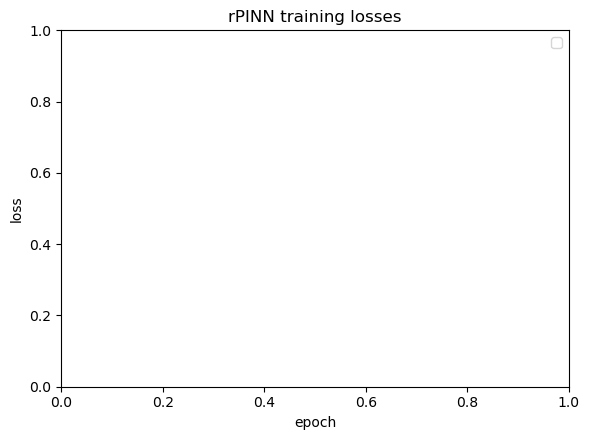

In [198]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rpinn_losses(
    rpinn_out,
    mode="mean",
    show_all_samples=True,
    show_map=True,
    keys=("data_nll", "physics_nll"),
    logy=False,
    idx=None,
):
    import numpy as np
    import matplotlib.pyplot as plt

    samples = rpinn_out.get("map", None)
    map_out = rpinn_out.get("map", None)

    if idx is None:
        idx = len(samples[0]["history"][keys[0]])

    plt.figure(figsize=(6, 4.5))

    for key in keys:

        # MAP loss
        if show_map and map_out is not None:
            map_loss = np.array(map_out["history"][key])[:idx]
            plt.plot(
                map_loss,
                linewidth=2.5,
                linestyle="--",
                label=f"MAP {key}",
            )

        # All samples
        if show_all_samples:
            for s in samples:
                loss = np.array(s["history"][key])[:idx]
                plt.plot(loss, alpha=0.25)

        # Mean loss
        if mode == "mean":
            stack = np.stack([np.array(s["history"][key])[:idx] for s in samples], axis=0)
            mean_loss = stack.mean(axis=0)
            plt.plot(mean_loss, linewidth=2, label=f"mean {key}")

    if logy:
        plt.yscale("log")

    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("rPINN training losses")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_rpinn_losses(
    rpinn_out,
    mode=None,
    show_all_samples=False,
    show_map=True,
    keys=("data_nll", "physics_nll"),
    logy=False,
    idx=0
)

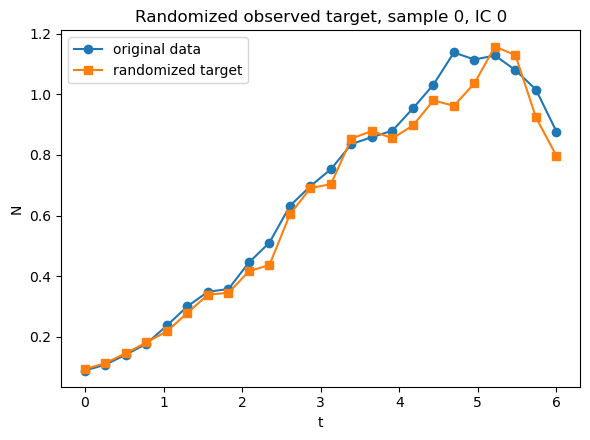

In [199]:

# ============================================================
# Inspect one randomized data target used by rPINN
# ============================================================
sample_idx = 0
ic_idx = 0

plot_randomized_targets_example(
    t_obs=t_obs,
    y_data_all=y_data_all,
    posterior_results=rpinn_out,
    ic_idx=ic_idx,
)


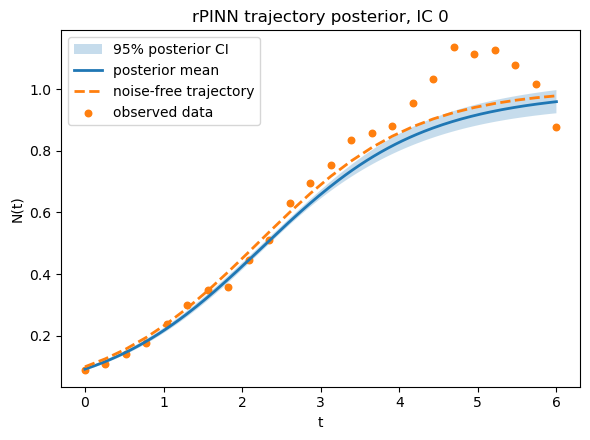

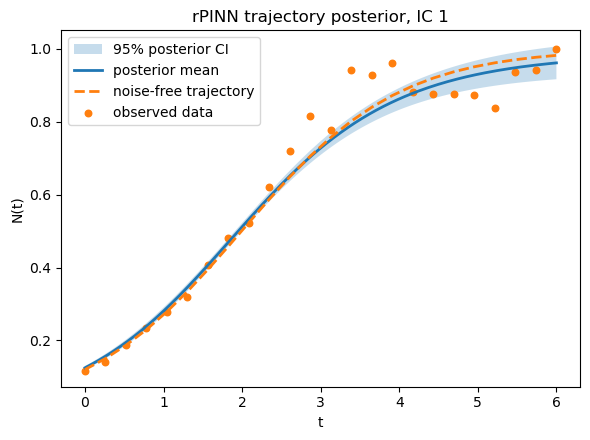

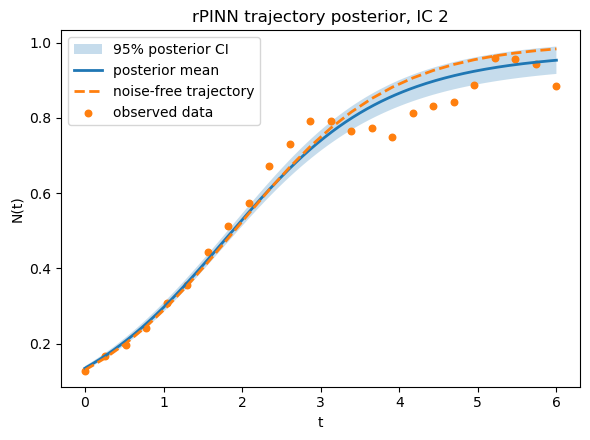

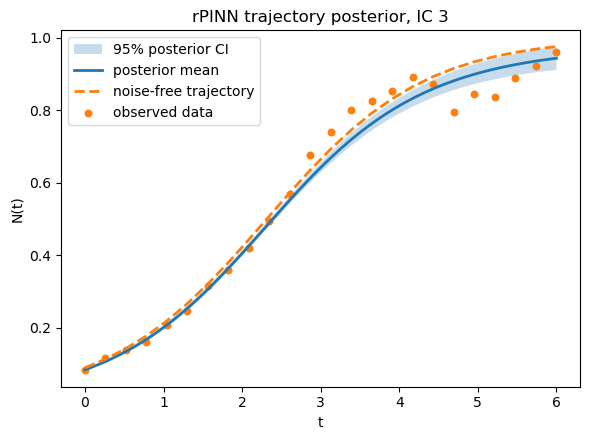

In [302]:

def plot_rpinn_dynamics_posterior(
    t_plot,
    y_data_all,
    y_true_all,
    posterior_results,
    ic_idx=0,
    outpath=None,
):
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

    t_plot_np = torch.as_tensor(t_plot).detach().cpu().numpy().reshape(-1)

    y_data_np = torch.as_tensor(y_data_all).detach().cpu().numpy().squeeze(-1)
    y_true_np = torch.as_tensor(y_true_all).detach().cpu().numpy().squeeze(-1)

    mean_np = posterior_results["traj_mean"][ic_idx].detach().cpu().numpy().reshape(-1)
    lo_np = posterior_results["traj_lo"][ic_idx].detach().cpu().numpy().reshape(-1)
    hi_np = posterior_results["traj_hi"][ic_idx].detach().cpu().numpy().reshape(-1)

    # observation times
    t_obs = np.linspace(t_plot_np.min(), t_plot_np.max(), y_data_np.shape[1])

    plt.figure(figsize=(6, 4.5))

    # posterior band
    plt.fill_between(t_plot_np, lo_np, hi_np, alpha=0.25, label="95% posterior CI")

    # posterior mean
    plt.plot(t_plot_np, mean_np, linewidth=2, label="posterior mean")

    # noise-free trajectory
    plt.plot(
        t_obs,
        y_true_np[ic_idx],
        linestyle="--",
        linewidth=2,
        label="noise-free trajectory",
    )

    # observed noisy data
    plt.scatter(t_obs, y_data_np[ic_idx], s=22, label="observed data")

    plt.xlabel("t")
    plt.ylabel("N(t)")
    plt.title(f"rPINN trajectory posterior, IC {ic_idx}")
    plt.legend()
    plt.tight_layout()

    if outpath is not None:
        plt.savefig(outpath, dpi=180, bbox_inches="tight")

    plt.show()
    
# ============================================================
# Posterior trajectory plots
# ============================================================
for ic_idx in range(n_ics):
    plot_rpinn_dynamics_posterior(
        t_plot=t_plot,
        y_data_all=y_data_all,
        y_true_all=y_true_all,
        posterior_results=rpinn_out,
        ic_idx=ic_idx,
    )


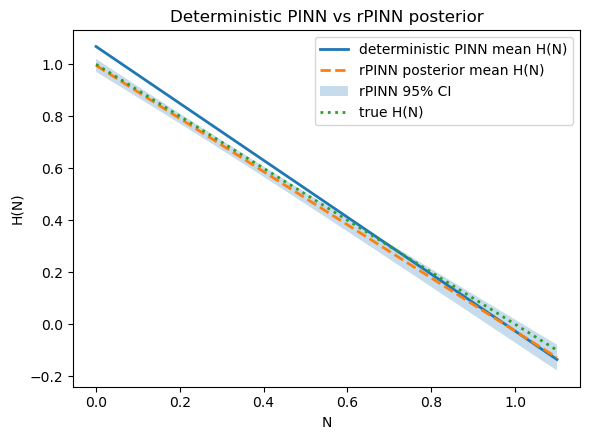

In [303]:

# ============================================================
# Compare deterministic PINN and rPINN posterior mean
# ============================================================
import matplotlib.pyplot as plt

N_grid_np = N_grid.squeeze(1).cpu().numpy()
rhs_mean_np = np.asarray(rhs_mean)
rpinn_H_mean_np = rpinn_out["H_mean"].cpu().numpy()

plt.figure(figsize=(6, 4.5))
plt.plot(N_grid_np, rhs_mean_np, linewidth=2, label="deterministic PINN mean H(N)")
plt.plot(N_grid_np, rpinn_H_mean_np, linewidth=2, linestyle="--", label="rPINN posterior mean H(N)")
plt.fill_between(
    N_grid_np,
    rpinn_out["H_lo"].cpu().numpy(),
    rpinn_out["H_hi"].cpu().numpy(),
    alpha=0.25,
    label="rPINN 95% CI",
)
if "H_grid_true" in globals():
    plt.plot(N_grid_np, H_grid_true.squeeze(1).cpu().numpy(), linestyle=":", linewidth=2, label="true H(N)")
plt.xlabel("N")
plt.ylabel("H(N)")
plt.title("Deterministic PINN vs rPINN posterior")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# Optional: summarize posterior spread numerically
# ============================================================
H_width = (rpinn_out["H_hi"] - rpinn_out["H_lo"]).cpu().numpy()
traj_width_ic0 = (rpinn_out["traj_hi"][0] - rpinn_out["traj_lo"][0]).cpu().numpy()

print("Posterior spread summary")
print("------------------------")
print(f"mean H 95% width: {H_width.mean():.6e}")
print(f"max  H 95% width: {H_width.max():.6e}")
print(f"IC 0 mean trajectory 95% width: {traj_width_ic0.mean():.6e}")
print(f"IC 0 max  trajectory 95% width: {traj_width_ic0.max():.6e}")


Posterior spread summary
------------------------
mean H 95% width: 2.326769e-02
max  H 95% width: 4.710209e-02
IC 0 mean trajectory 95% width: 4.503377e-02
IC 0 max  trajectory 95% width: 9.580994e-02


### Notes

- The **data perturbation** uses the learned `sigma_data(N)` together with the learned `rho` in an **AR(1)** model, so the randomized observations preserve the temporal correlation structure.
- The **physics perturbation** uses `sigma_physics(N)` with **independent Gaussian perturbations at collocation points**, which is appropriate because the collocation points are resampled rather than treated as a time-ordered sequence.
- If you want a tighter or wider posterior, the main knobs are `n_samples`, `lambda_anchor`, and `prior_std`.
